In [1]:
!pip install -q transformers datasets scikit-learn torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 56.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from google.colab import files

uploaded = files.upload()
archivo = list(uploaded.keys())[0]  # nombre automático
df = pd.read_excel(archivo)

# Mostramos columnas para asegurarnos
print("Columnas:", df.columns)


Saving 00_base.xlsx to 00_base.xlsx
Columnas: Index(['Law', 'Article', 'Spanish text', 'Relevance', 'Interpretability',
       'Completeness', 'Differential Regime', 'Discretionality'],
      dtype='object')


In [4]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_es = set(stopwords.words('spanish'))

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+", "", texto)
    texto = re.sub(r"[^a-záéíóúñü\s]", "", texto)
    palabras = texto.split()
    palabras = [w for w in palabras if w not in stop_es and len(w) > 2]
    return " ".join(palabras)

df['texto_limpio'] = df['Spanish text'].apply(limpiar_texto)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
def get_embeddings(texts, model_name, batch_size=16):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()
    embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True, return_tensors='pt')
            output = model(**encoded)
            cls_embeddings = output.last_hidden_state[:, 0, :].numpy()
            embeddings.append(cls_embeddings)

    return np.vstack(embeddings)


In [7]:
def entrenar_y_evaluar(df, categoria, modelo_name, nombre_amigable):
    datos = df[['texto_limpio', categoria]].dropna()
    X = datos['texto_limpio'].tolist()
    y = datos[categoria]

    # Dividir
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Embeddings
    print(f"🔄 Obteniendo embeddings para {categoria} – {nombre_amigable}")
    X_train_embed = get_embeddings(X_train, modelo_name)
    X_test_embed = get_embeddings(X_test, modelo_name)

    # Clasificador
    clf = LogisticRegression(max_iter=2000, class_weight='balanced')
    clf.fit(X_train_embed, y_train)
    y_pred = clf.predict(X_test_embed)

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    etiquetas = sorted(y.unique())

    # Matriz
    cm = confusion_matrix(y_test, y_pred, labels=etiquetas, normalize='true')
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=etiquetas, yticklabels=etiquetas)
    plt.title(f"Matriz de Confusión – {nombre_amigable} – {categoria}")
    plt.xlabel("Predicción"); plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    # Mostrar métricas
    print(classification_report(y_test, y_pred, digits=3))

    # Errores
    errores_df = pd.DataFrame({
        'Texto': X_test,
        'Real': y_test,
        'Predicción': y_pred,
        'Modelo': nombre_amigable,
        'Categoría': categoria
    })
    errores_df = errores_df[errores_df['Real'] != errores_df['Predicción']]

    macro = report['macro avg']
    weighted = report['weighted avg']

    resumen = {
        'Modelo': nombre_amigable,
        'Categoría': categoria,
        'Accuracy': round(acc, 3),
        'F1 Macro': round(macro['f1-score'], 3),
        'F1 Weighted': round(weighted['f1-score'], 3),
        'Precision Macro': round(macro['precision'], 3),
        'Recall Macro': round(macro['recall'], 3)
    }

    return resumen, errores_df


🔄 Obteniendo embeddings para Relevance – BETO


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


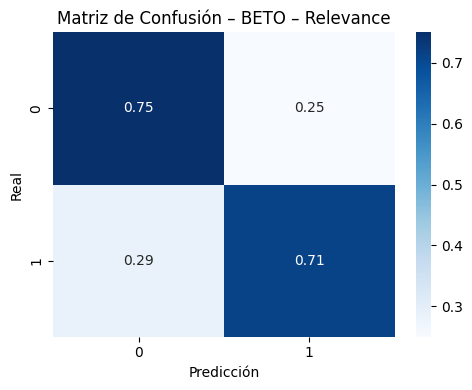

              precision    recall  f1-score   support

           0      0.789     0.750     0.769        20
           1      0.667     0.714     0.690        14

    accuracy                          0.735        34
   macro avg      0.728     0.732     0.729        34
weighted avg      0.739     0.735     0.736        34

🔄 Obteniendo embeddings para Relevance – BERT Multilingüe


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

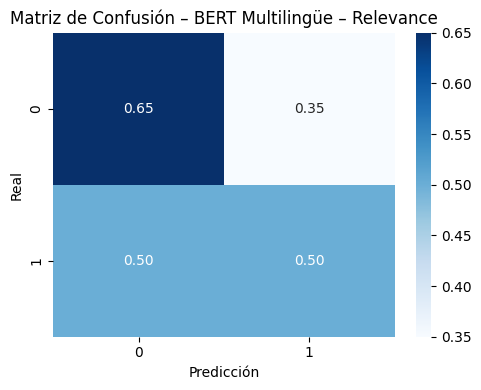

              precision    recall  f1-score   support

           0      0.650     0.650     0.650        20
           1      0.500     0.500     0.500        14

    accuracy                          0.588        34
   macro avg      0.575     0.575     0.575        34
weighted avg      0.588     0.588     0.588        34

🔄 Obteniendo embeddings para Relevance – DistilBERT


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

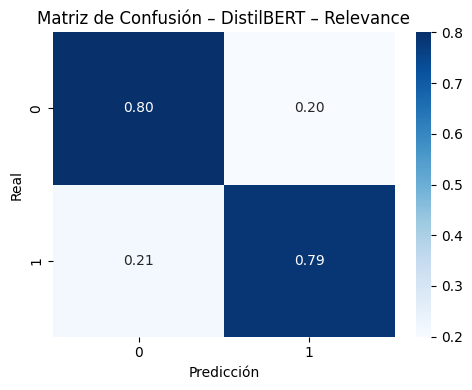

              precision    recall  f1-score   support

           0      0.842     0.800     0.821        20
           1      0.733     0.786     0.759        14

    accuracy                          0.794        34
   macro avg      0.788     0.793     0.790        34
weighted avg      0.797     0.794     0.795        34

🔄 Obteniendo embeddings para Interpretability – BETO


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


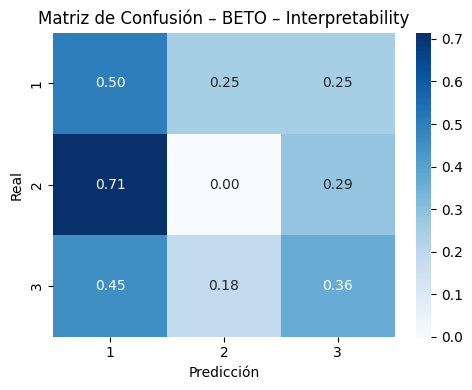

              precision    recall  f1-score   support

           1      0.444     0.500     0.471        16
           2      0.000     0.000     0.000         7
           3      0.400     0.364     0.381        11

    accuracy                          0.353        34
   macro avg      0.281     0.288     0.284        34
weighted avg      0.339     0.353     0.345        34

🔄 Obteniendo embeddings para Interpretability – BERT Multilingüe


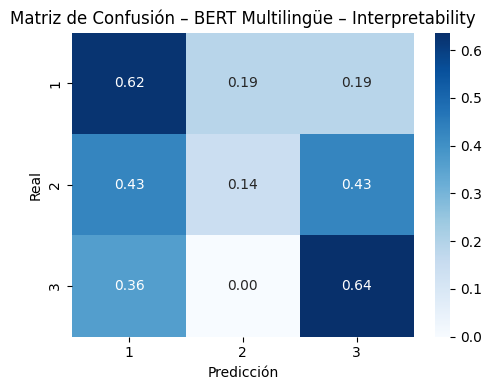

              precision    recall  f1-score   support

           1      0.588     0.625     0.606        16
           2      0.250     0.143     0.182         7
           3      0.538     0.636     0.583        11

    accuracy                          0.529        34
   macro avg      0.459     0.468     0.457        34
weighted avg      0.502     0.529     0.511        34

🔄 Obteniendo embeddings para Interpretability – DistilBERT


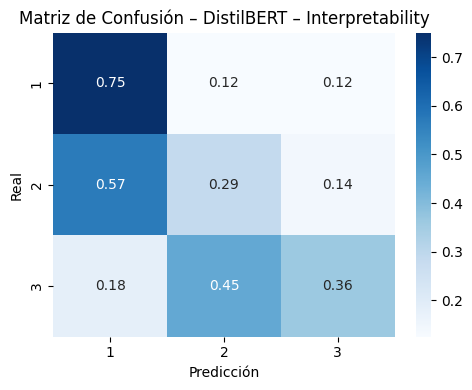

              precision    recall  f1-score   support

           1      0.667     0.750     0.706        16
           2      0.222     0.286     0.250         7
           3      0.571     0.364     0.444        11

    accuracy                          0.529        34
   macro avg      0.487     0.466     0.467        34
weighted avg      0.544     0.529     0.527        34

🔄 Obteniendo embeddings para Completeness – BETO


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


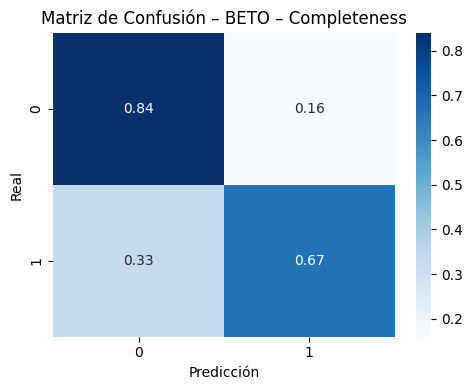

              precision    recall  f1-score   support

           0      0.875     0.840     0.857        25
           1      0.600     0.667     0.632         9

    accuracy                          0.794        34
   macro avg      0.738     0.753     0.744        34
weighted avg      0.802     0.794     0.797        34

🔄 Obteniendo embeddings para Completeness – BERT Multilingüe


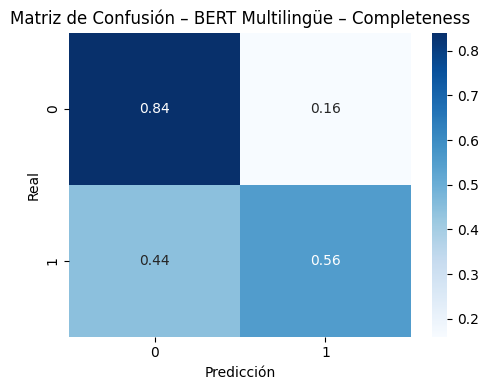

              precision    recall  f1-score   support

           0      0.840     0.840     0.840        25
           1      0.556     0.556     0.556         9

    accuracy                          0.765        34
   macro avg      0.698     0.698     0.698        34
weighted avg      0.765     0.765     0.765        34

🔄 Obteniendo embeddings para Completeness – DistilBERT


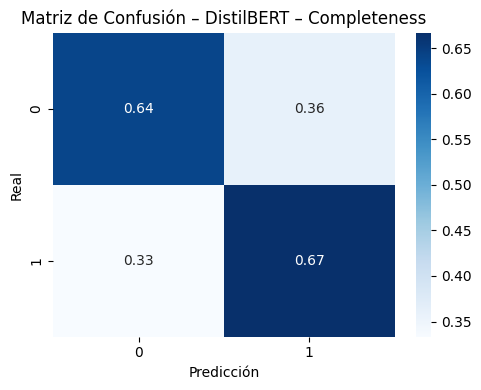

              precision    recall  f1-score   support

           0      0.842     0.640     0.727        25
           1      0.400     0.667     0.500         9

    accuracy                          0.647        34
   macro avg      0.621     0.653     0.614        34
weighted avg      0.725     0.647     0.667        34

🔄 Obteniendo embeddings para Differential Regime – BETO


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


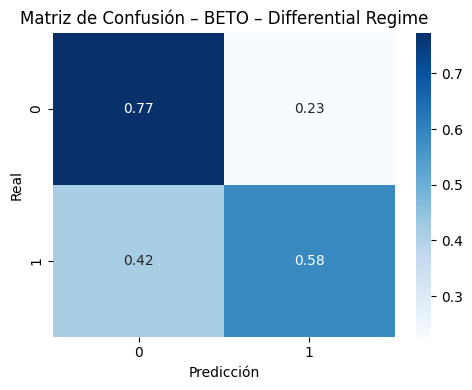

              precision    recall  f1-score   support

           0      0.773     0.773     0.773        22
           1      0.583     0.583     0.583        12

    accuracy                          0.706        34
   macro avg      0.678     0.678     0.678        34
weighted avg      0.706     0.706     0.706        34

🔄 Obteniendo embeddings para Differential Regime – BERT Multilingüe


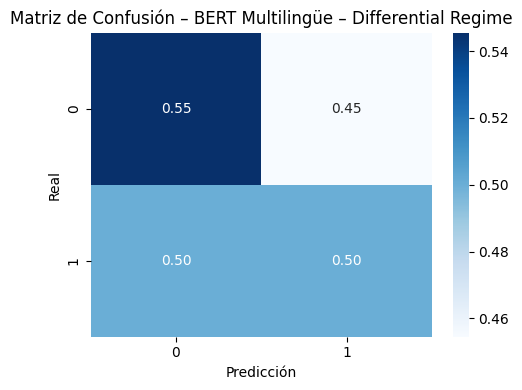

              precision    recall  f1-score   support

           0      0.667     0.545     0.600        22
           1      0.375     0.500     0.429        12

    accuracy                          0.529        34
   macro avg      0.521     0.523     0.514        34
weighted avg      0.564     0.529     0.539        34

🔄 Obteniendo embeddings para Differential Regime – DistilBERT


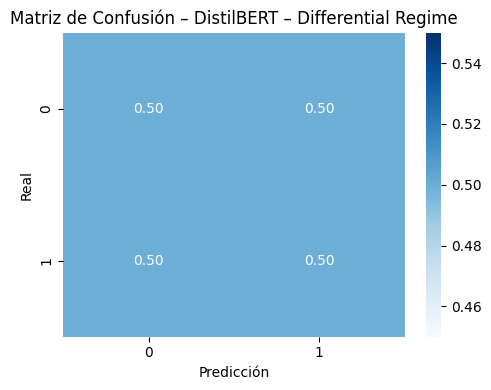

              precision    recall  f1-score   support

           0      0.647     0.500     0.564        22
           1      0.353     0.500     0.414        12

    accuracy                          0.500        34
   macro avg      0.500     0.500     0.489        34
weighted avg      0.543     0.500     0.511        34

🔄 Obteniendo embeddings para Discretionality – BETO


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


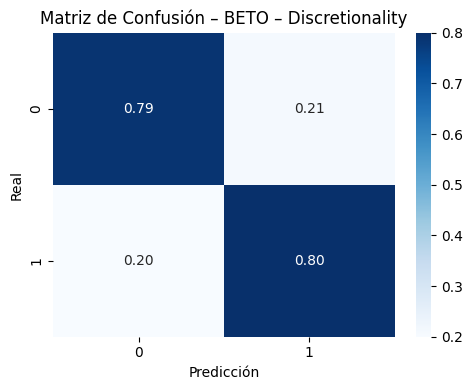

              precision    recall  f1-score   support

           0      0.833     0.789     0.811        19
           1      0.750     0.800     0.774        15

    accuracy                          0.794        34
   macro avg      0.792     0.795     0.793        34
weighted avg      0.797     0.794     0.795        34

🔄 Obteniendo embeddings para Discretionality – BERT Multilingüe


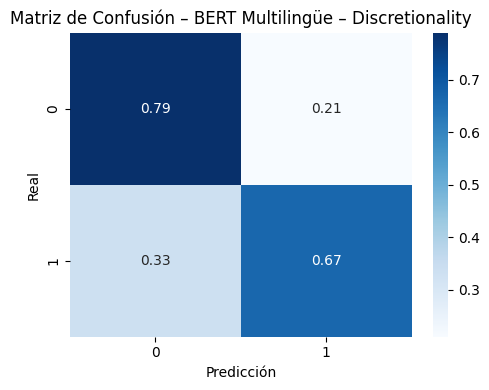

              precision    recall  f1-score   support

           0      0.750     0.789     0.769        19
           1      0.714     0.667     0.690        15

    accuracy                          0.735        34
   macro avg      0.732     0.728     0.729        34
weighted avg      0.734     0.735     0.734        34

🔄 Obteniendo embeddings para Discretionality – DistilBERT


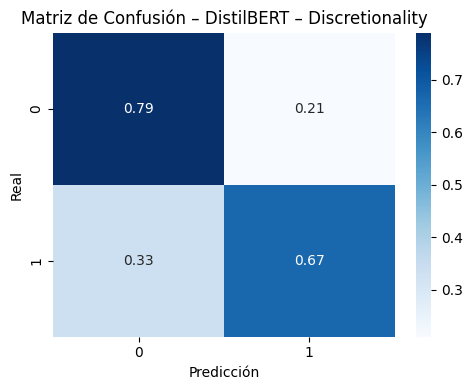

              precision    recall  f1-score   support

           0      0.750     0.789     0.769        19
           1      0.714     0.667     0.690        15

    accuracy                          0.735        34
   macro avg      0.732     0.728     0.729        34
weighted avg      0.734     0.735     0.734        34



In [8]:
# Modelos a probar
modelos = [
    ("dccuchile/bert-base-spanish-wwm-cased", "BETO"),
    ("bert-base-multilingual-cased", "BERT Multilingüe"),
    ("distilbert-base-multilingual-cased", "DistilBERT")
]

# Categorías a evaluar
categorias = ['Relevance', 'Interpretability', 'Completeness', 'Differential Regime', 'Discretionality']

resultados = []
errores_todos = []

# 🔁 Para cada categoría y cada modelo
for cat in categorias:
    for modelo_id, nombre_amigable in modelos:
        print("="*100)
        resumen, errores = entrenar_y_evaluar(df, cat, modelo_id, nombre_amigable)
        resultados.append(resumen)
        errores_todos.append(errores)


In [9]:
# Tabla final
df_resultados = pd.DataFrame(resultados)
print("📊 Comparativa de modelos:")
display(df_resultados)

# Errores
df_errores = pd.concat(errores_todos, ignore_index=True)
print(f"\n❌ Total de errores: {len(df_errores)}")
display(df_errores.head())

# Exportar (opcional)
df_resultados.to_excel("resultados_transformer.xlsx", index=False)
df_errores.to_excel("errores_transformer.xlsx", index=False)


📊 Comparativa de modelos:


,Modelo,Categoría,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
0,BETO,Relevance,0.735,0.729,0.736,0.728,0.732
1,BERT Multilingüe,Relevance,0.588,0.575,0.588,0.575,0.575
2,DistilBERT,Relevance,0.794,0.790,0.795,0.788,0.793
3,BETO,Interpretability,0.353,0.284,0.345,0.281,0.288
4,BERT Multilingüe,Interpretability,0.529,0.457,0.511,0.459,0.468
5,DistilBERT,Interpretability,0.529,0.467,0.527,0.487,0.466
6,BETO,Completeness,0.794,0.744,0.797,0.738,0.753
7,BERT Multilingüe,Completeness,0.765,0.698,0.765,0.698,0.698
8,DistilBERT,Completeness,0.647,0.614,0.667,0.621,0.653
9,BETO,Differential Regime,0.706,0.678,0.706,0.678,0.678



❌ Total de errores: 179


,Texto,Real,Predicción,Modelo,Categoría
0,adiciónese artículo estatuto tributario siguie...,1,0,BETO,Relevance
1,pacto subregional andino personas proyecten be...,0,1,BETO,Relevance
2,pacto andino empresas industriales instaladas ...,0,1,BETO,Relevance
3,régimen libertad cambiaria fin facilitar cumpl...,0,1,BETO,Relevance
4,régimen empresas extranjeras empresas extranje...,1,0,BETO,Relevance
